<font color="FF3B3B"><h1 align="left">Sistema multimodal para la detección e identificación de especies de hongos mediante visión por computador y modelos de lenguaje</h1></font>
<font color="#6E6E6E"><h2 align="left">Entrenamiento del modelo complejo</h2></font>

#### David Alejandro Pedroza De Jesús

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shutil
import os
import tensorflow as tf
from google.colab import drive
from tensorflow.keras import layers, models
import shutil
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from keras.utils import plot_model
from tensorflow.keras import activations

In [3]:
drive.mount('/content/drive/')
shutil.copy("/content/drive/MyDrive/kaggle.zip","/content/")
!unzip kaggle.zip
#shutil.copy("/content/drive/MyDrive/InfoEspecies.csv","/content/")

Se han truncado las últimas 5000 líneas del flujo de salida.
  inflating: kaggle/working/merged_dataset/Xanthoria parietina/39104medium.jpeg  
  inflating: kaggle/working/merged_dataset/Xanthoria parietina/39105medium.jpeg  
  inflating: kaggle/working/merged_dataset/Xanthoria parietina/39106medium.jpg  
  inflating: kaggle/working/merged_dataset/Xanthoria parietina/39107medium.jpg  
  inflating: kaggle/working/merged_dataset/Xanthoria parietina/39108medium.jpg  
  inflating: kaggle/working/merged_dataset/Xanthoria parietina/39109medium.jpg  
  inflating: kaggle/working/merged_dataset/Xanthoria parietina/39110medium.jpeg  
  inflating: kaggle/working/merged_dataset/Xanthoria parietina/39111medium.jpeg  
  inflating: kaggle/working/merged_dataset/Xanthoria parietina/39112medium.jpg  
  inflating: kaggle/working/merged_dataset/Xanthoria parietina/39113medium.jpeg  
  inflating: kaggle/working/merged_dataset/Xanthoria parietina/39114medium.jpg  
  inflating: kaggle/working/merged_dataset/

# Carga de los datos

In [4]:
rutas_val = pd.read_csv("kaggle/working/val.csv")
rutas_train = pd.read_csv("kaggle/working/train.csv")
rutas_test = pd.read_csv("kaggle/working/test.csv")
info_especies = pd.read_csv("InfoEspecies.csv")
info_especies = info_especies.drop(info_especies.columns[0], axis= "columns")

train = pd.merge(info_especies, rutas_train, on='label', how='inner')
test = pd.merge(info_especies, rutas_test, on='label', how='inner')
val = pd.merge(info_especies, rutas_val, on='label', how='inner')

In [5]:

def ArreglarLasRutas(df):
    rutas_nuevas = []
    for path in df.image_path:
        path = path.lstrip("/")
        rutas_nuevas.append(path)
    df.image_path = rutas_nuevas

def Modificar_direc(df_rutas, subset):
    os.makedirs(f"Data/{subset}", exist_ok=True)

    ArreglarLasRutas(df_rutas)

    for path, label in zip(df_rutas.image_path, df_rutas.label):
        destino = f"Data/{subset}/{label}/"
        os.makedirs(destino, exist_ok=True)
        print(f"Copiando {path} --> {destino}")
        shutil.copy(path, destino)
        print(f"Terminado {label}")

In [6]:
Modificar_direc(train, "train")
Modificar_direc(test, "test")
Modificar_direc(val, "valid")

Se han truncado las últimas 5000 líneas del flujo de salida.
Copiando kaggle/working/merged_dataset/Fomitopsis pinicola/23452medium.jpeg --> Data/valid/Fomitopsis pinicola/
Terminado Fomitopsis pinicola
Copiando kaggle/working/merged_dataset/Fomitopsis pinicola/22011medium.jpeg --> Data/valid/Fomitopsis pinicola/
Terminado Fomitopsis pinicola
Copiando kaggle/working/merged_dataset/Fomitopsis pinicola/20680medium.jpeg --> Data/valid/Fomitopsis pinicola/
Terminado Fomitopsis pinicola
Copiando kaggle/working/merged_dataset/Fomitopsis pinicola/21100medium.jpg --> Data/valid/Fomitopsis pinicola/
Terminado Fomitopsis pinicola
Copiando kaggle/working/merged_dataset/Fomitopsis pinicola/19837medium.jpeg --> Data/valid/Fomitopsis pinicola/
Terminado Fomitopsis pinicola
Copiando kaggle/working/merged_dataset/Fomitopsis pinicola/23382medium.jpeg --> Data/valid/Fomitopsis pinicola/
Terminado Fomitopsis pinicola
Copiando kaggle/working/merged_dataset/Fomitopsis pinicola/19047medium.jpeg --> Data/val

In [7]:
train_dir = "Data/train"
test_dir = "Data/test"
val_dir = "Data/valid"


train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    image_size=(64, 64),
    batch_size=128,
    label_mode='int'
)
test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    image_size=(64, 64),
    batch_size=128,
    label_mode='int'
)
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    val_dir,
    image_size=(64, 64),
    batch_size=128,
    label_mode='int'
)

normalization_layer = layers.Rescaling(1./255)
train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
test_ds = test_ds.map(lambda x, y: (normalization_layer(x), y))
valid_ds = val_ds.map(lambda x, y: (normalization_layer(x), y))

Found 30068 files belonging to 54 classes.
Found 6442 files belonging to 54 classes.
Found 6443 files belonging to 54 classes.


# Creamos el modelo

In [15]:
num_classes = 54


model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(64,64,3)),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3)),
    layers.BatchNormalization(),
    layers.Activation(activations.relu),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(128, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.Activation(activations.relu),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(num_classes, activation='softmax')
])


model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

history = model.fit(train_ds, epochs=60, validation_data=valid_ds)

test_loss, test_acc = model.evaluate(test_ds)
print(f"Precisión en test: {test_acc:.4f}")

Epoch 1/60
235/235 ━━━━━━━━━━━━━━━━━━━━ 113s 435ms/step - accuracy: 0.3015 - loss: 2.8824 - val_accuracy: 0.2878 - val_loss: 3.7750
Epoch 2/60
235/235 ━━━━━━━━━━━━━━━━━━━━ 91s 386ms/step - accuracy: 0.4236 - loss: 2.1974 - val_accuracy: 0.3576 - val_loss: 2.5225
Epoch 3/60
235/235 ━━━━━━━━━━━━━━━━━━━━ 74s 315ms/step - accuracy: 0.4846 - loss: 1.8961 - val_accuracy: 0.4200 - val_loss: 2.2155
Epoch 4/60
235/235 ━━━━━━━━━━━━━━━━━━━━ 79s 305ms/step - accuracy: 0.5315 - loss: 1.7028 - val_accuracy: 0.4155 - val_loss: 2.6121
Epoch 5/60
235/235 ━━━━━━━━━━━━━━━━━━━━ 62s 263ms/step - accuracy: 0.5686 - loss: 1.5367 - val_accuracy: 0.4344 - val_loss: 2.5137
Epoch 6/60
235/235 ━━━━━━━━━━━━━━━━━━━━ 64s 274ms/step - accuracy: 0.6071 - loss: 1.3827 - val_accuracy: 0.4108 - val_loss: 2.4258
Epoch 7/60
235/235 ━━━━━━━━━━━━━━━━━━━━ 70s 299ms/step - accuracy: 0.6427 - loss: 1.2345 - val_accuracy: 0.4054 - val_loss: 2.4885
Epoch 8/60
235/235 ━━━━━━━━━━━━━━━━━━━━ 61s 258ms/step - accuracy: 0.6748 - loss: 

# Arquitectura del modelo

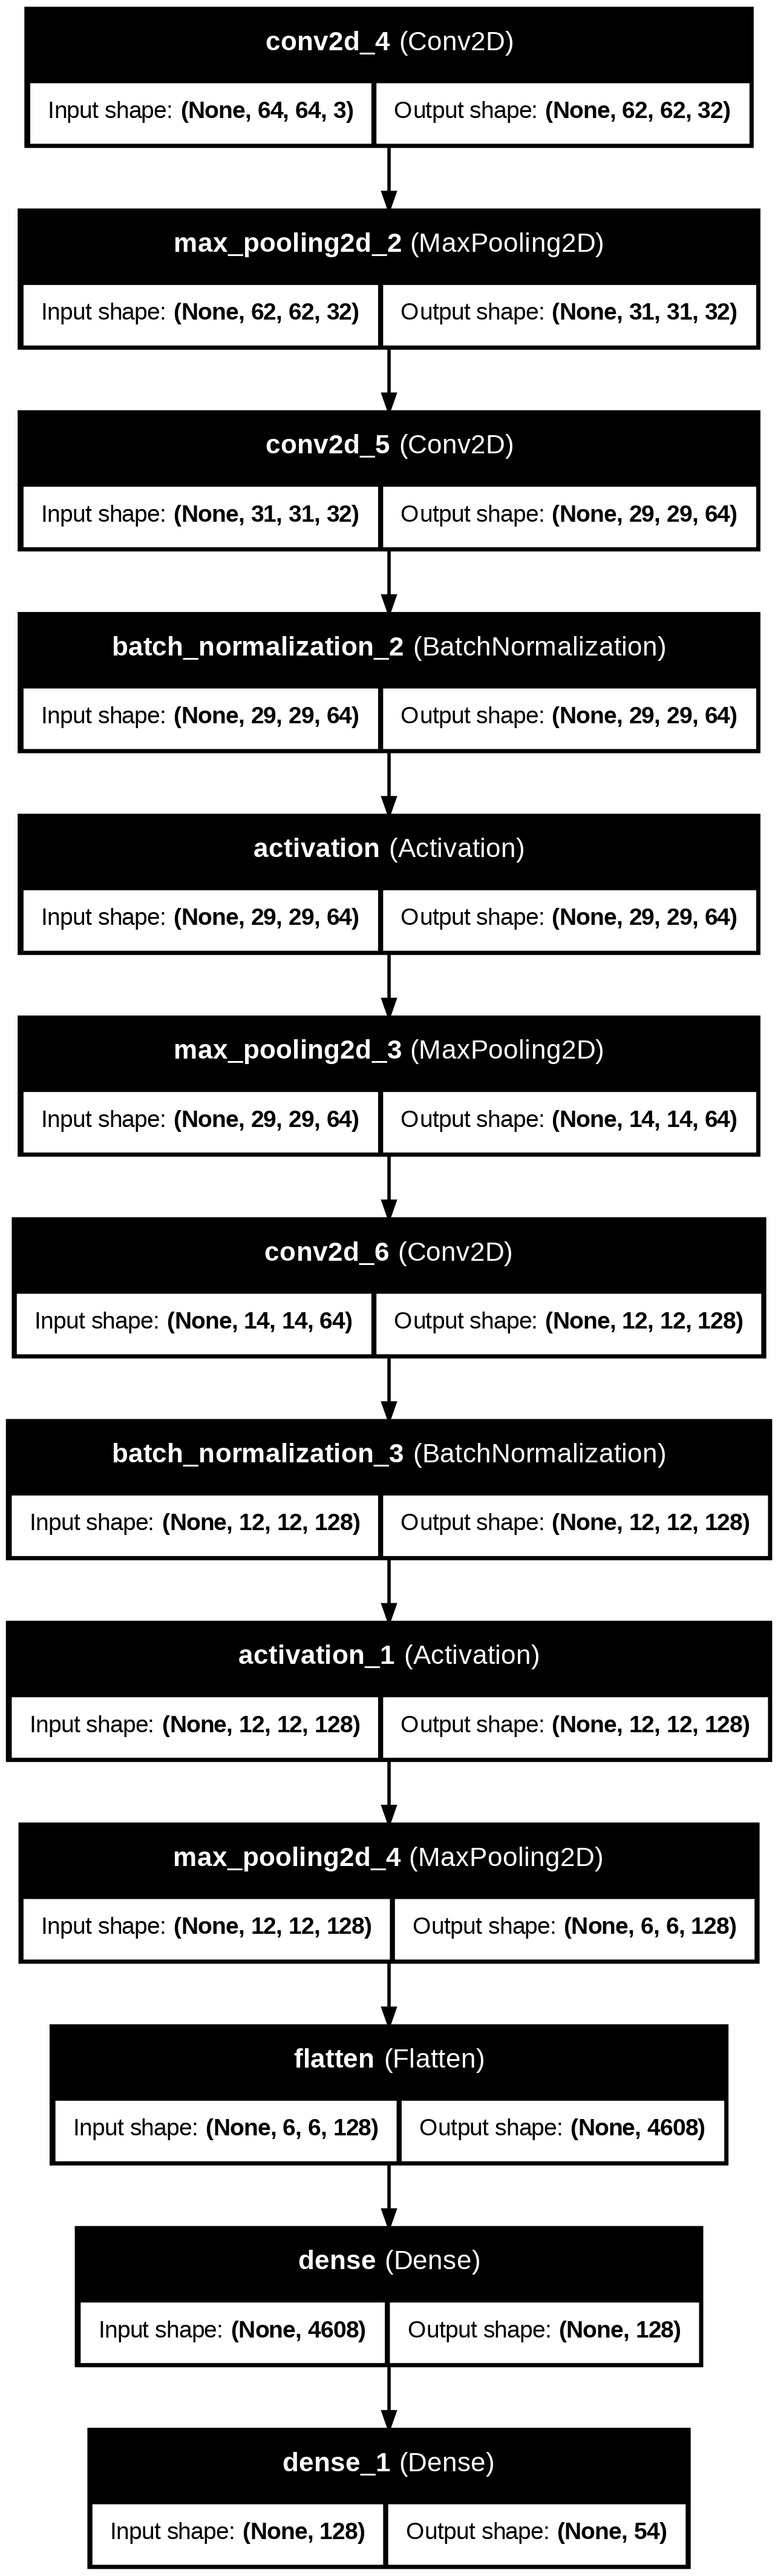

In [16]:
plot_model(model, to_file='modelo.png', show_shapes=True, show_layer_names=True)

# graficos error

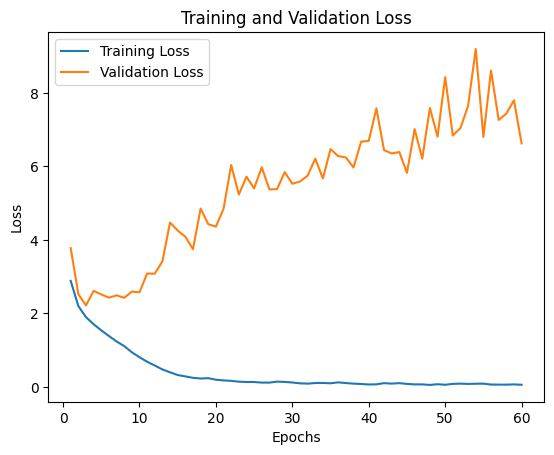

In [17]:
train_loss = history.history['loss']
val_loss = history.history['val_loss']

plt.plot(list(range(1,61)),train_loss, label='Training Loss')
plt.plot(list(range(1,61)),val_loss,label='Validation Loss')
plt.legend()
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.show()

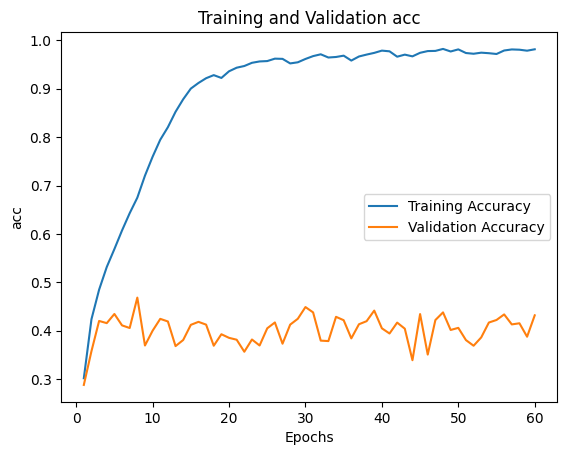

In [18]:
val_acc = history.history['val_accuracy']
train_acc = history.history['accuracy']
plt.plot(list(range(1,61)),train_acc, label='Training Accuracy')
plt.plot(list(range(1,61)),val_acc,label='Validation Accuracy')
plt.legend()
plt.title('Training and Validation acc')
plt.xlabel('Epochs')
plt.ylabel('acc')
plt.show()

# matriz de confusión

In [19]:
# Inicializar listas
y_true = []
y_pred = []

# Iterar sobre el dataset de prueba
for images, labels in test_ds:
    y_true.extend(labels.numpy())                        # Labels reales
    preds = model.predict(images)                        # Predicciones del modelo
    y_pred.extend(np.argmax(preds, axis=1))              # Clase con mayor probabilidad

# Convertir a arrays de numpy
y_true = np.array(y_true)
y_pred = np.array(y_pred)

4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
4/4 ━━━━━━━━━

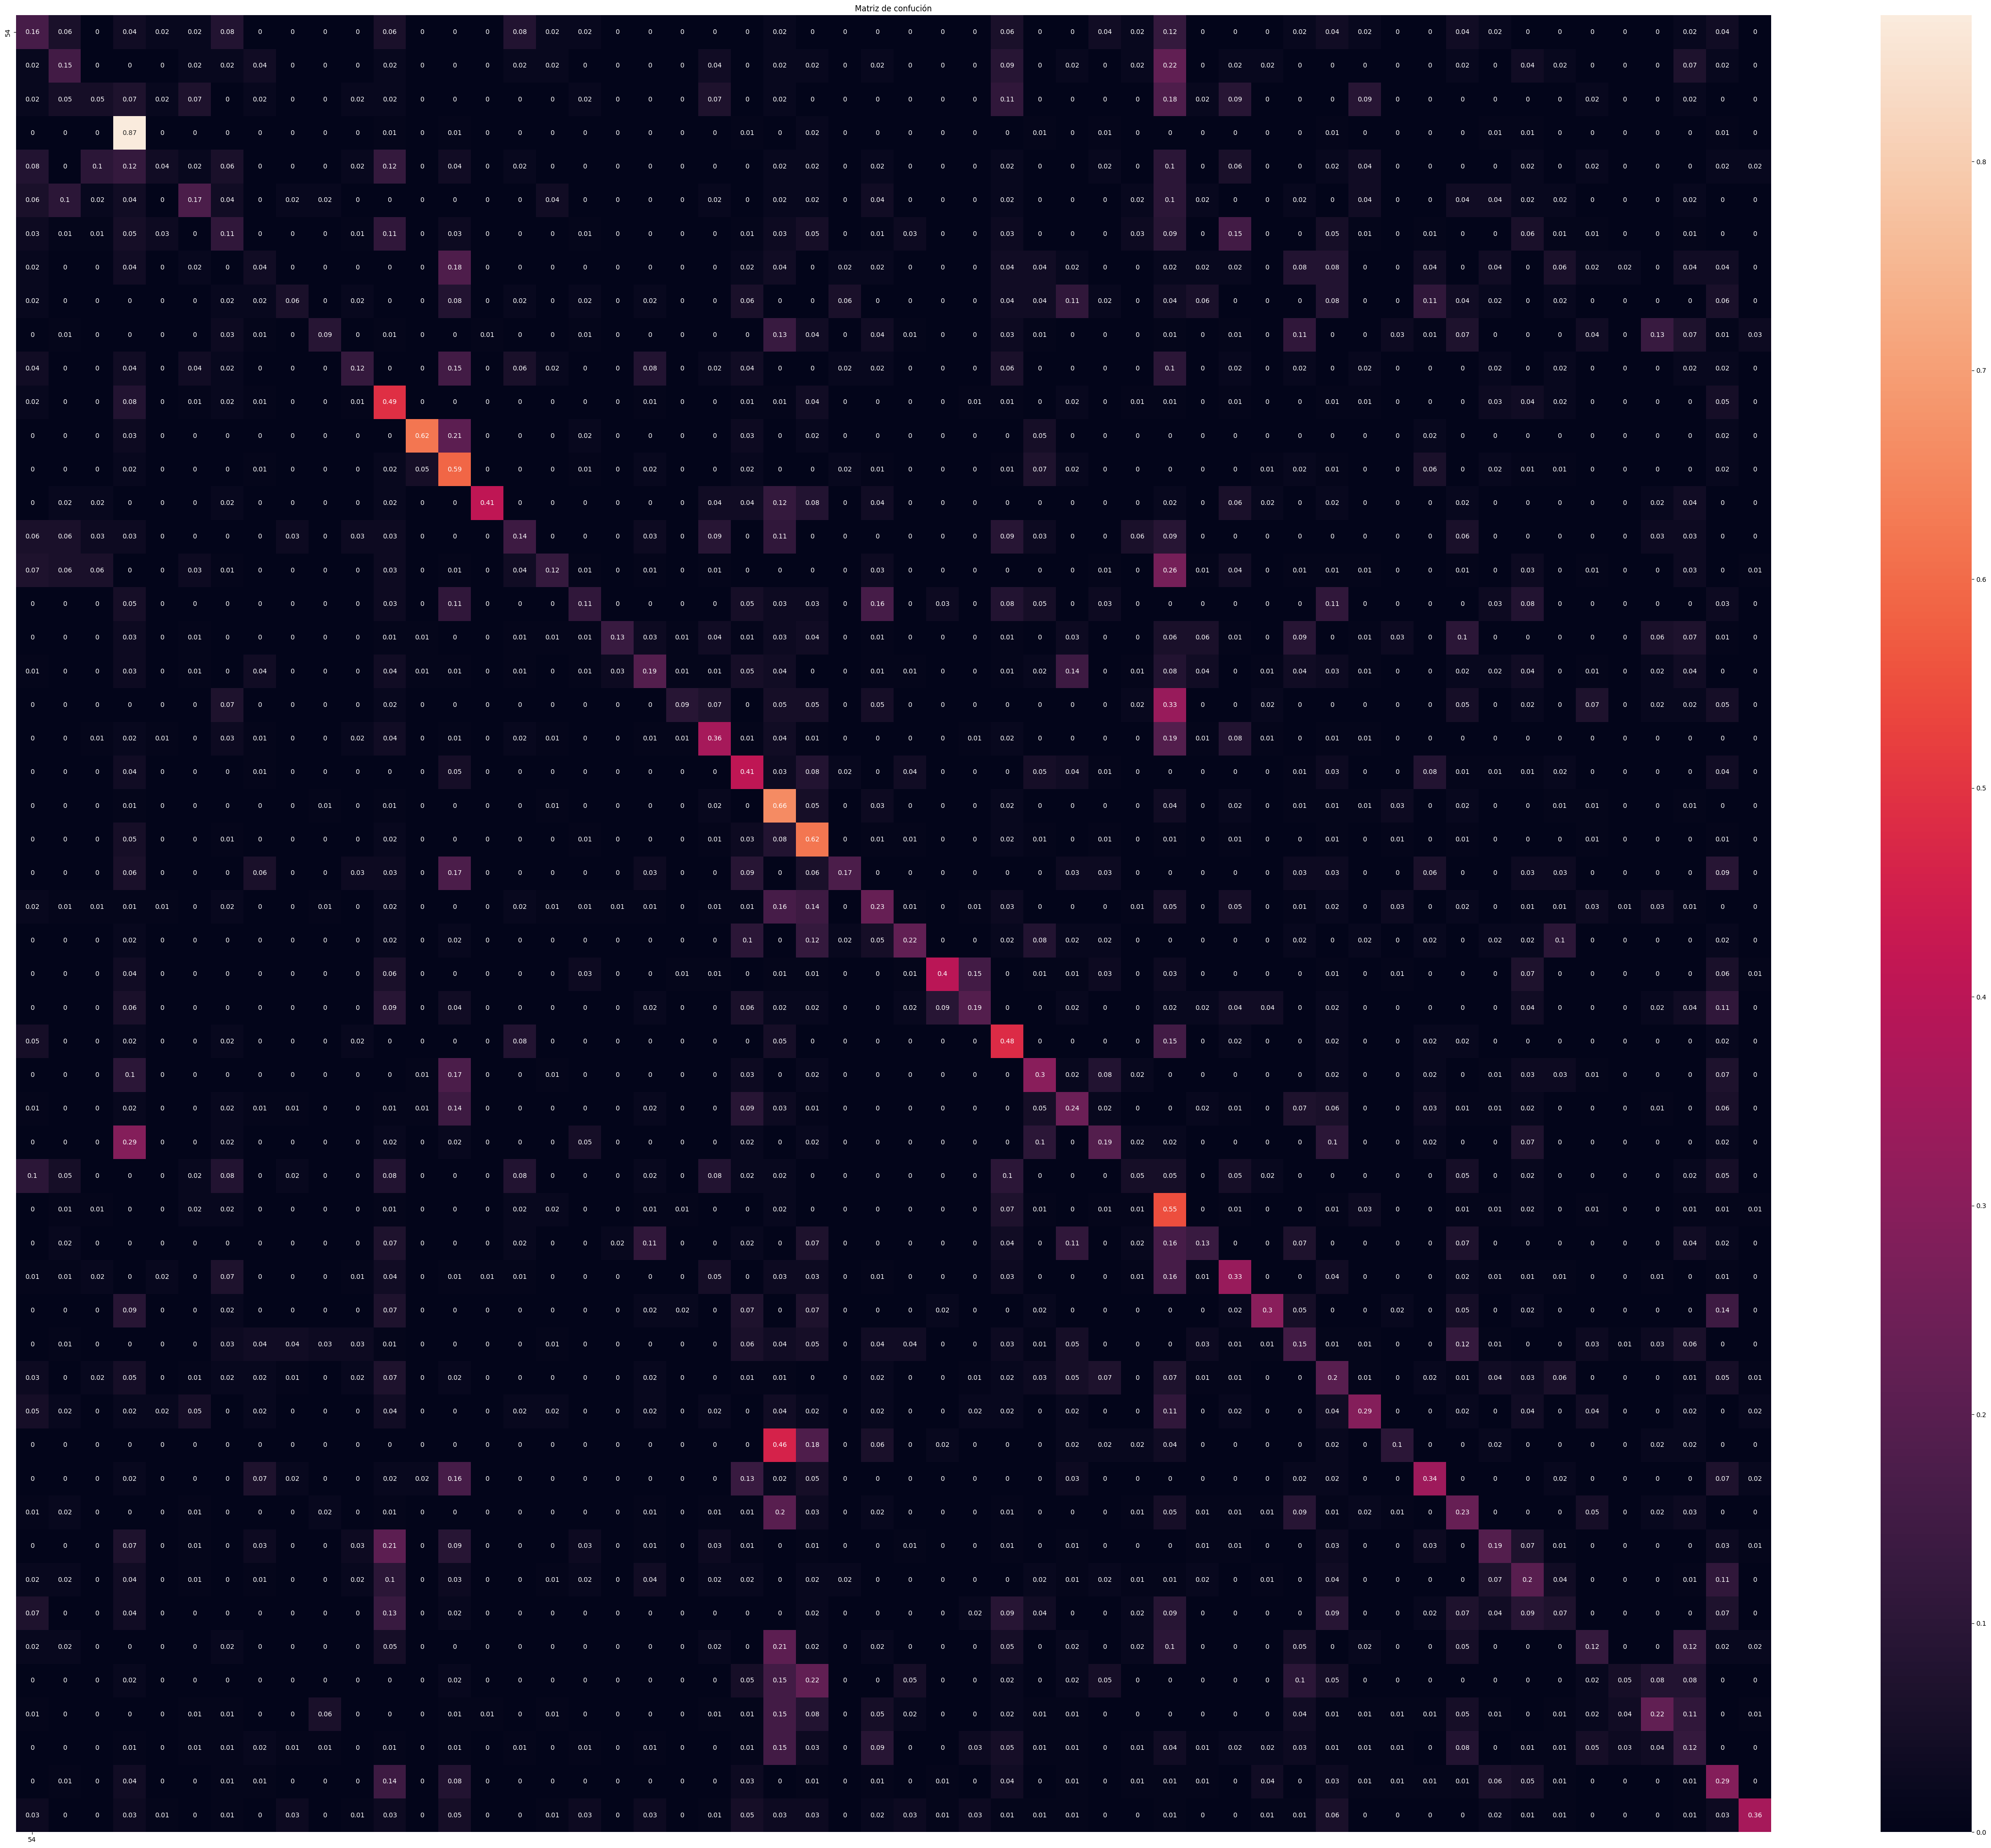

In [20]:
cm = confusion_matrix(y_true,y_pred ,normalize= "true").round(2)
plt.subplots(figsize=(60,50))
sns.heatmap(cm,xticklabels= info_especies.label.shape, yticklabels=info_especies.label.shape,annot=True)
plt.title("Matriz de confución")
plt.show()

In [21]:
print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

           0       0.11      0.16      0.13        51
           1       0.15      0.15      0.15        46
           2       0.06      0.05      0.05        44
           3       0.78      0.87      0.82       687
           4       0.11      0.04      0.06        51
           5       0.20      0.17      0.18        48
           6       0.11      0.11      0.11        79
           7       0.05      0.04      0.04        49
           8       0.17      0.06      0.08        53
           9       0.21      0.09      0.12        70
          10       0.18      0.12      0.15        48
          11       0.38      0.49      0.43       220
          12       0.72      0.62      0.67        63
          13       0.33      0.59      0.42       126
          14       0.81      0.41      0.55        51
          15       0.10      0.14      0.12        35
          16       0.25      0.12      0.16        68
          17       0.11    